# M5 Forecasting - Accuracy

In [1]:
import gc
from pathlib import Path
from typing import Any, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data")
RANDOM_STATE = 42

ID_COLS = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

CALENDAR_DTYPES = {
    "wm_yr_wk": "int16",
    "weekday": "category",
    "wday": "int8",
    "month": "int8",
    "year": "int16",
    "d": "category",
    "event_name_1": "category",
    "event_type_1": "category",
    "event_name_2": "category",
    "event_type_2": "category",
    "snap_CA": "int8",
    "snap_TX": "int8",
    "snap_WI": "int8",
}

PRICE_DTYPES = {
    "store_id": "category",
    "item_id": "category",
    "wm_yr_wk": "int16",
    "sell_price": "float32",
}

SUBMISSION_DTYPES = {"id": "category", **{f"F{i}": "float32" for i in range(1, 29)}}


def sales_dtypes(path: Path) -> dict[str, str]:
    header = pd.read_csv(path, nrows=0).columns
    dtypes = {col: "category" for col in ID_COLS}
    dtypes.update({col: "int16" for col in header if col.startswith("d_")})
    return dtypes


def memory_mb(df: pd.DataFrame) -> float:
    return df.memory_usage(deep=True).sum() / 1024**2


def day_columns(df: pd.DataFrame) -> list[str]:
    return sorted([c for c in df.columns if c.startswith("d_")], key=lambda x: int(x[2:]))

## Загрузка данных

In [2]:
calendar = pd.read_csv(DATA_DIR / "calendar.csv", dtype=cast(Any, CALENDAR_DTYPES), parse_dates=["date"])
prices = pd.read_csv(DATA_DIR / "sell_prices.csv", dtype=cast(Any, PRICE_DTYPES))
sales_val = pd.read_csv(DATA_DIR / "sales_train_validation.csv", dtype=cast(Any, sales_dtypes(DATA_DIR / "sales_train_validation.csv")))
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv", dtype=cast(Any, SUBMISSION_DTYPES))

sales_eval_columns = pd.read_csv(DATA_DIR / "sales_train_evaluation.csv", nrows=0).columns.tolist()

tables = {
    "calendar": calendar,
    "prices": prices,
    "sales_validation": sales_val,
    "sample_submission": sample_submission,
}

pd.DataFrame(
    {
        "rows": {name: len(df) for name, df in tables.items()},
        "columns": {name: df.shape[1] for name, df in tables.items()},
        "memory_mb": {name: memory_mb(df) for name, df in tables.items()},
    }
).round(2)

,rows,columns,memory_mb
calendar,1969,14,0.21
prices,6841121,4,58.96
sales_validation,30490,1919,115.00
sample_submission,60980,29,13.28


In [3]:
for name, df in tables.items():
    print(f"\n{name}: {df.shape}")
    display(df.head())


calendar: (1969, 14)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1



prices: (6841121, 4)


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26



sales_validation: (30490, 1919)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,...,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,4,2,0,2,0,1,1,0,1,0,0,1,1,3,0,0,0,1,1,1,3,1,3,1,2,2,0,1,1,1,1,0,0,0,0,0,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6,1,1,2,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,1,0,0,0,0,0,0,2,0,1,0,0,...,2,3,0,6,0,0,0,1,0,1,5,3,1,0,0,0,1,2,3,0,1,3,4,2,1,4,1,3,5,0,6,6,0,0,0,0,3,1,2,1,3,1,0,2,5,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,3,1,1,1,1,2,1,0,0,1,0,2,1,1,0,3,1,1,2,1,1,0,3,2,2,2,3,1,0,0,0,0,1,0,4,4,0,1,4,0,1,0,1,0,1,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4



sample_submission: (60980, 29)


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,HOBBIES_1_001_CA_1_validation,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,HOBBIES_1_002_CA_1_validation,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,HOBBIES_1_003_CA_1_validation,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,HOBBIES_1_004_CA_1_validation,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,HOBBIES_1_005_CA_1_validation,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Проверка структуры и пропусков

In [4]:
def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    result = pd.DataFrame({"missing": df.isna().sum()})
    result["missing_pct"] = result["missing"] / len(df) * 100
    return result.query("missing > 0").sort_values("missing_pct", ascending=False)

for name, df in tables.items():
    print(f"\n{name}")
    display(missing_report(df).head(20))


calendar


,missing,missing_pct
event_type_2,1964,99.746064
event_name_2,1964,99.746064
event_type_1,1807,91.772473
event_name_1,1807,91.772473



prices


,missing,missing_pct



sales_validation


,missing,missing_pct



sample_submission


,missing,missing_pct


In [5]:
id_cols = ID_COLS
day_cols_val = day_columns(sales_val)
day_cols_eval = sorted([c for c in sales_eval_columns if c.startswith("d_")], key=lambda x: int(x[2:]))

print(f"Validation day columns: {day_cols_val[0]} ... {day_cols_val[-1]} ({len(day_cols_val)})")
print(f"Evaluation day columns: {day_cols_eval[0]} ... {day_cols_eval[-1]} ({len(day_cols_eval)})")
display(sales_val[id_cols].nunique().to_frame("nunique"))
display(sales_val.groupby(["state_id", "store_id"], observed=True).size().to_frame("items"))

Validation day columns: d_1 ... d_1913 (1913)
Evaluation day columns: d_1 ... d_1941 (1941)


,nunique
id,30490
item_id,3049
dept_id,7
cat_id,3
store_id,10
state_id,3


items
state_id store_id       
CA       CA_1       3049
         CA_2       3049
         CA_3       3049
         CA_4       3049
TX       TX_1       3049
         TX_2       3049
         TX_3       3049
WI       WI_1       3049
         WI_2       3049
         WI_3       3049

## Продажи во времени

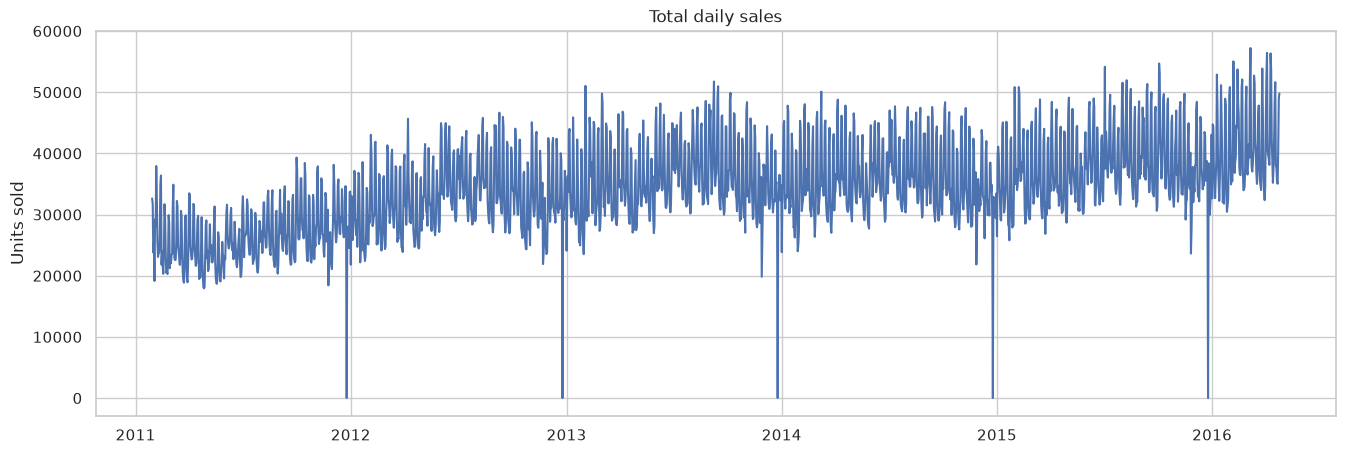

In [6]:
daily_sales = sales_val[day_cols_val].sum(axis=0).rename("sales").reset_index()
daily_sales = daily_sales.rename(columns={"index": "d"}).merge(calendar[["d", "date", "wday", "weekday", "month", "year"]], on="d", how="left")

fig, ax = plt.subplots(figsize=(16, 5))
sns.lineplot(data=daily_sales, x="date", y="sales", ax=ax)
ax.set_title("Total daily sales")
ax.set_xlabel("")
ax.set_ylabel("Units sold")
plt.show()

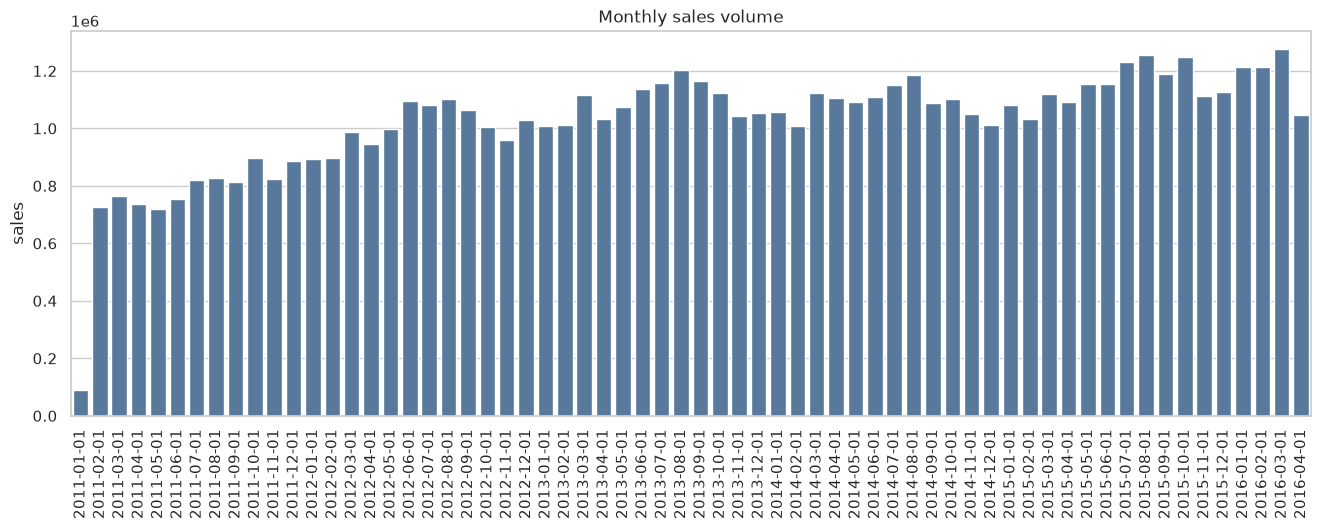

In [7]:
monthly_sales = daily_sales.assign(month_start=daily_sales["date"].dt.to_period("M").dt.to_timestamp())
monthly_sales = monthly_sales.groupby("month_start", as_index=False)["sales"].sum()

fig, ax = plt.subplots(figsize=(16, 5))
sns.barplot(data=monthly_sales, x="month_start", y="sales", color="#4C78A8", ax=ax)
ax.tick_params(axis="x", rotation=90)
ax.set_title("Monthly sales volume")
ax.set_xlabel("")
plt.show()

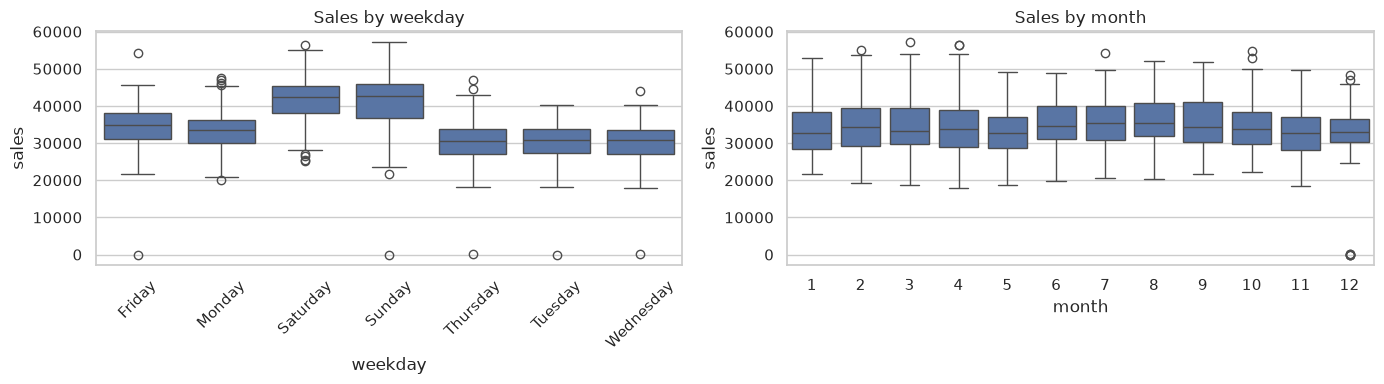

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=daily_sales, x="weekday", y="sales", ax=axes[0])
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("Sales by weekday")

sns.boxplot(data=daily_sales, x="month", y="sales", ax=axes[1])
axes[1].set_title("Sales by month")
plt.tight_layout()
plt.show()

## Разрезы по штатам, магазинам и категориям

In [9]:
sales_by_state = sales_val.groupby("state_id")[day_cols_val].sum().T
sales_by_state.index = calendar.set_index("d").loc[sales_by_state.index, "date"]

sales_by_store = sales_val.groupby("store_id")[day_cols_val].sum().T
sales_by_store.index = calendar.set_index("d").loc[sales_by_store.index, "date"]

sales_by_cat = sales_val.groupby("cat_id")[day_cols_val].sum().T
sales_by_cat.index = calendar.set_index("d").loc[sales_by_cat.index, "date"]

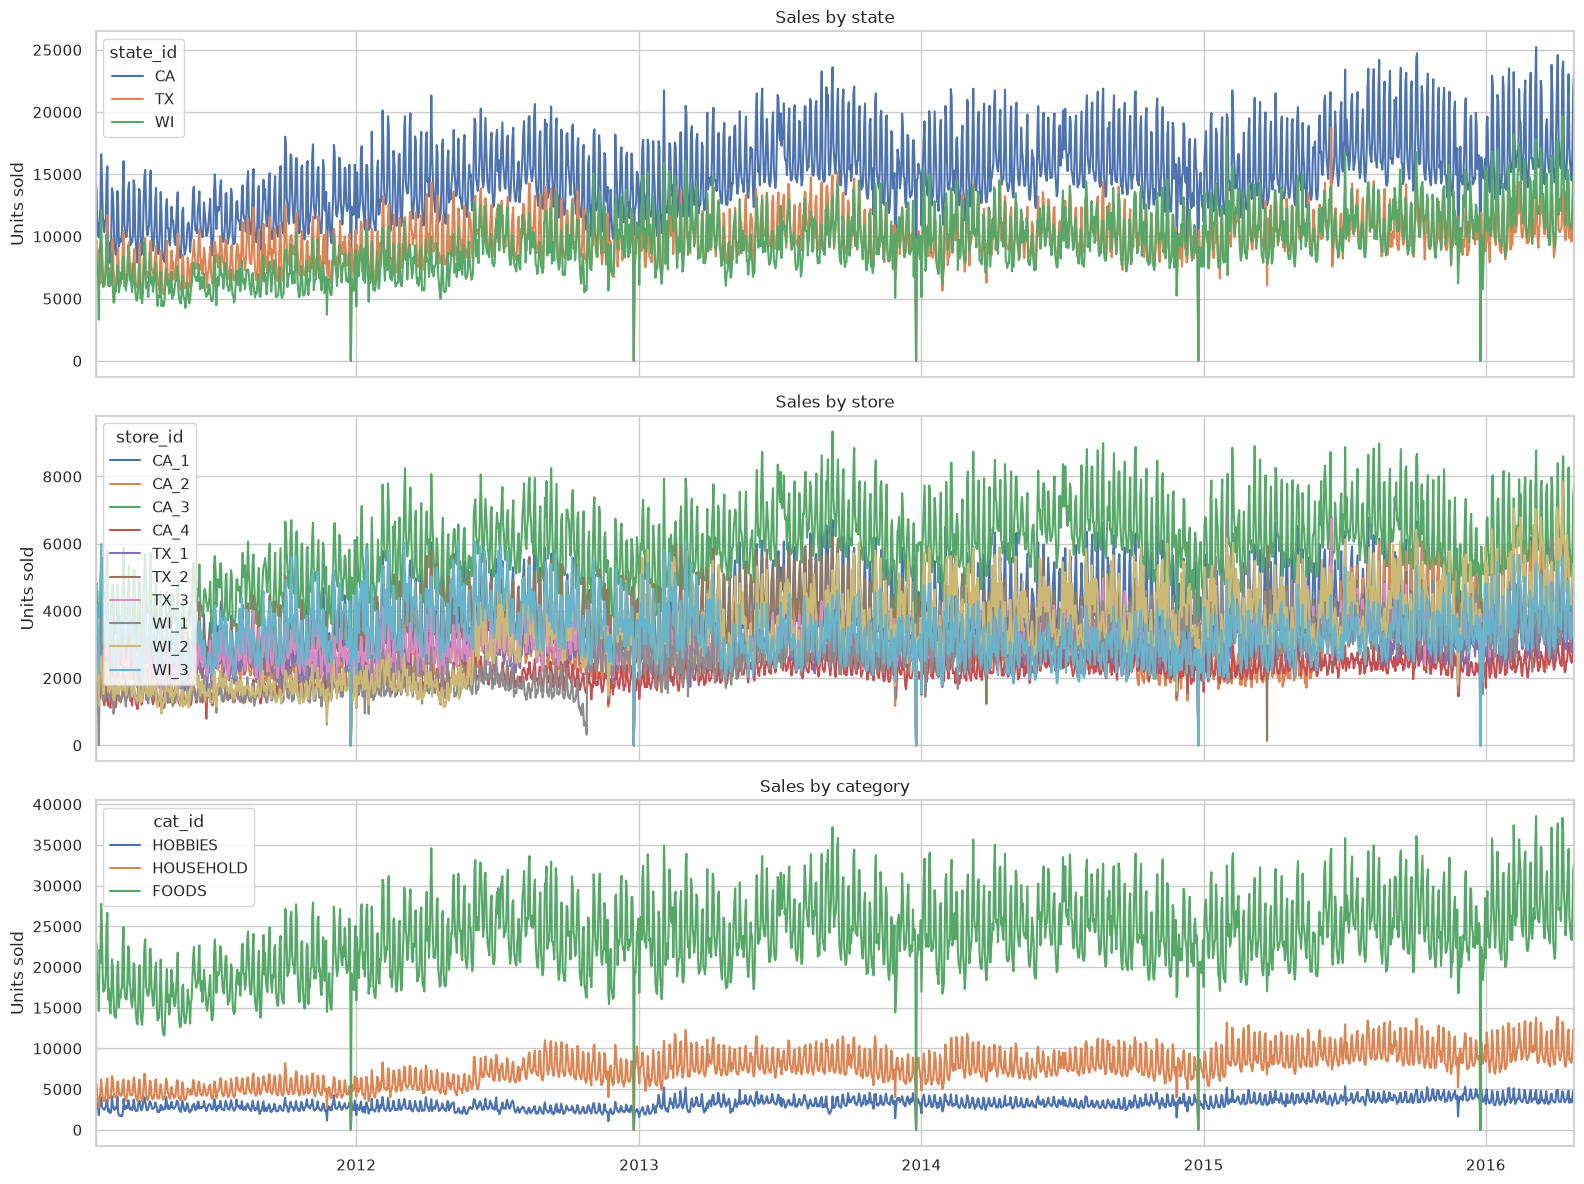

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
sales_by_state.plot(ax=axes[0], title="Sales by state")
sales_by_store.plot(ax=axes[1], title="Sales by store")
sales_by_cat.plot(ax=axes[2], title="Sales by category")
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Units sold")
plt.tight_layout()
plt.show()

## Распределение спроса и товары с нулевыми продажами

In [11]:
item_stats = sales_val[id_cols].copy()
item_stats["total_sales"] = sales_val[day_cols_val].sum(axis=1)
item_stats["mean_sales"] = sales_val[day_cols_val].mean(axis=1)
item_stats["zero_days_pct"] = (sales_val[day_cols_val].eq(0).sum(axis=1) / len(day_cols_val) * 100)

display(item_stats[["total_sales", "mean_sales", "zero_days_pct"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).T)
display(item_stats.sort_values("total_sales", ascending=False).head(20))

,count,mean,std,min,25%,50%,75%,90%,99%,max
total_sales,30490.0,2154.654280,5217.226438,10.000000,355.000000,848.000000,2031.750000,4676.000000,21076.250000,250502.000000
mean_sales,30490.0,1.126322,2.727249,0.005227,0.185572,0.443283,1.062075,2.444328,11.017381,130.947203
zero_days_pct,30490.0,68.196276,22.377330,0.156822,53.685311,73.549399,86.722426,93.047569,97.543126,99.634083


,id,item_id,dept_id,cat_id,store_id,state_id,total_sales,mean_sales,zero_days_pct
8412,FOODS_3_090_CA_3_validation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,250502,130.947203,18.766336
18055,FOODS_3_586_TX_2_validation,FOODS_3_586,FOODS_3,FOODS,TX_2,TX,192835,100.802405,0.418191
21104,FOODS_3_586_TX_3_validation,FOODS_3_586,FOODS_3,FOODS,TX_3,TX,150122,78.474647,0.365917
8908,FOODS_3_586_CA_3_validation,FOODS_3_586,FOODS_3,FOODS,CA_3,CA,134386,70.248824,0.261370
2314,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,127203,66.493988,24.516466
29755,FOODS_3_090_WI_3_validation,FOODS_3_090,FOODS_3,FOODS,WI_3,WI,121434,63.478306,25.405123
17559,FOODS_3_090_TX_2_validation,FOODS_3_090,FOODS_3,FOODS,TX_2,TX,119496,62.465238,24.621014
20608,FOODS_3_090_TX_3_validation,FOODS_3_090,FOODS_3,FOODS,TX_3,TX,114854,60.038683,24.673288
17721,FOODS_3_252_TX_2_validation,FOODS_3_252,FOODS_3,FOODS,TX_2,TX,114153,59.672243,0.209096
15006,FOODS_3_586_TX_1_validation,FOODS_3_586,FOODS_3,FOODS,TX_1,TX,112454,58.784109,0.731835


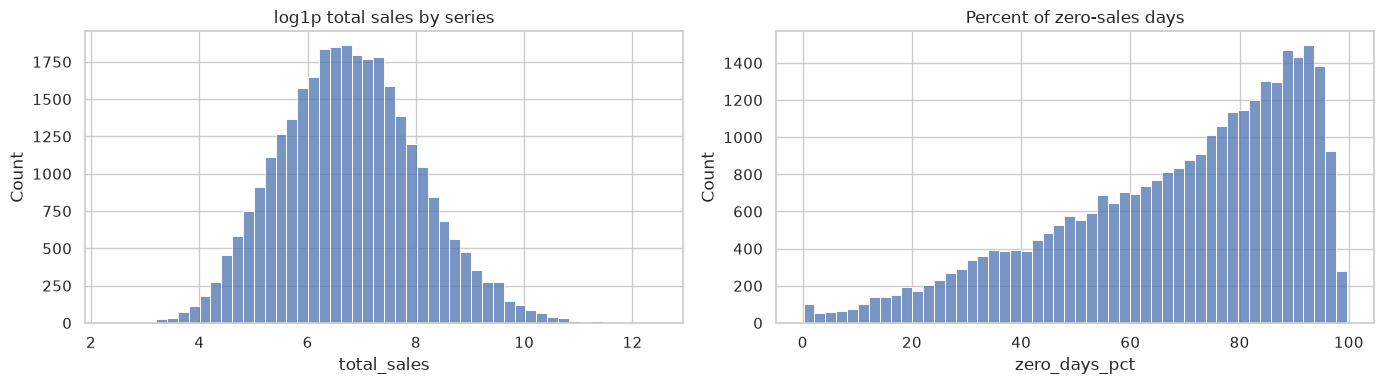

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(np.log1p(item_stats["total_sales"]), bins=50, ax=axes[0])
axes[0].set_title("log1p total sales by series")

sns.histplot(item_stats["zero_days_pct"], bins=50, ax=axes[1])
axes[1].set_title("Percent of zero-sales days")
plt.tight_layout()
plt.show()

## Календарные события и SNAP

In [13]:
event_days = calendar.loc[calendar["event_name_1"].notna(), ["date", "d", "event_name_1", "event_type_1"]]
display(event_days.head(20))
display(calendar[["snap_CA", "snap_TX", "snap_WI"]].mean().to_frame("share_of_days"))

,date,d,event_name_1,event_type_1
8,2011-02-06,d_9,SuperBowl,Sporting
16,2011-02-14,d_17,ValentinesDay,Cultural
23,2011-02-21,d_24,PresidentsDay,National
39,2011-03-09,d_40,LentStart,Religious
46,2011-03-16,d_47,LentWeek2,Religious
47,2011-03-17,d_48,StPatricksDay,Cultural
50,2011-03-20,d_51,Purim End,Religious
85,2011-04-24,d_86,OrthodoxEaster,Religious
87,2011-04-26,d_88,Pesach End,Religious
96,2011-05-05,d_97,Cinco De Mayo,Cultural


,share_of_days
snap_CA,0.330117
snap_TX,0.330117
snap_WI,0.330117


In [14]:
daily_with_events = daily_sales.merge(calendar[["d", "event_type_1", "snap_CA", "snap_TX", "snap_WI"]], on="d", how="left")
daily_with_events["has_event"] = daily_with_events["event_type_1"].notna()

display(daily_with_events.groupby("has_event")["sales"].agg(["count", "mean", "median", "std"]))
display(daily_with_events.groupby("event_type_1")["sales"].agg(["count", "mean", "median", "std"]).sort_values("mean", ascending=False))

,count,mean,median,std
has_event,,,,
False,1759,34489.207504,33714.0,7133.701801
True,154,32655.149351,33779.5,9300.905832


,count,mean,median,std
event_type_1,,,,
Sporting,16,35796.062500,34998.0,6651.926533
Cultural,35,34234.742857,35089.0,7380.081844
Religious,52,33760.692308,33760.0,7069.625055
National,51,29458.509804,32656.0,12117.064001


## Цены

count    6.841121e+06
mean     4.410953e+00
std      3.408814e+00
min      1.000000e-02
1%       4.800000e-01
5%       9.700000e-01
50%      3.470000e+00
95%      1.098000e+01
99%      1.792000e+01
max      1.073200e+02
Name: sell_price, dtype: float64

,count,mean,median,min,max
store_id,,,,,
CA_1,698412,4.41,3.47,0.01,30.980000
CA_2,637395,4.45,3.48,0.20,30.980000
CA_3,693990,4.39,3.44,0.01,30.980000
CA_4,679025,4.42,3.47,0.01,30.980000
TX_1,699796,4.37,3.42,0.05,52.619999
TX_2,701214,4.37,3.42,0.05,29.969999
TX_3,691112,4.39,3.44,0.02,30.980000
WI_1,665912,4.46,3.48,0.01,35.880001
WI_2,678171,4.44,3.47,0.05,61.459999


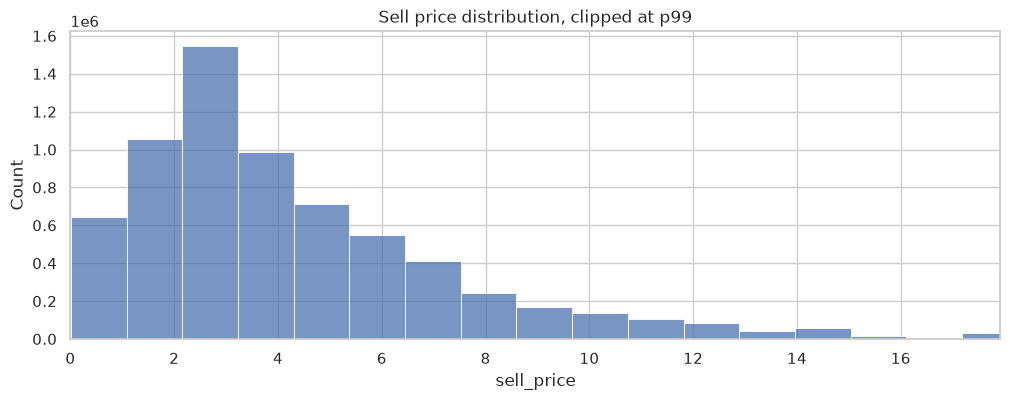

In [15]:
display(prices["sell_price"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
display(prices.groupby("store_id")["sell_price"].agg(["count", "mean", "median", "min", "max"]).round(2))

fig, ax = plt.subplots(figsize=(12, 4))
sns.histplot(prices["sell_price"], bins=100, ax=ax)
ax.set_xlim(0, prices["sell_price"].quantile(0.99))
ax.set_title("Sell price distribution, clipped at p99")
plt.show()

In [16]:
price_changes = (
    prices.sort_values(["store_id", "item_id", "wm_yr_wk"])
    .assign(price_change=lambda x: x.groupby(["store_id", "item_id"])["sell_price"].pct_change())
)
display(price_changes["price_change"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

count    6.810631e+06
mean     1.244816e-03
std      4.507183e-01
min     -9.988864e-01
1%       0.000000e+00
5%       0.000000e+00
50%      0.000000e+00
95%      0.000000e+00
99%      0.000000e+00
max      8.970000e+02
Name: price_change, dtype: float64

## Компактная long-выборка для проверки признаков

In [18]:
sample_ids = sales_val["id"].sample(1_000, random_state=RANDOM_STATE)
recent_days = day_cols_val[-180:]
sales_sample = sales_val.loc[sales_val["id"].isin(sample_ids), id_cols + recent_days]

long_sample = sales_sample.melt(id_vars=id_cols, value_vars=recent_days, var_name="d", value_name="sales")
long_sample = long_sample.merge(calendar, on="d", how="left")
long_sample = long_sample.merge(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")
long_sample["d_num"] = long_sample["d"].str[2:].astype(int)
long_sample.head()


del sales_sample
gc.collect()

0

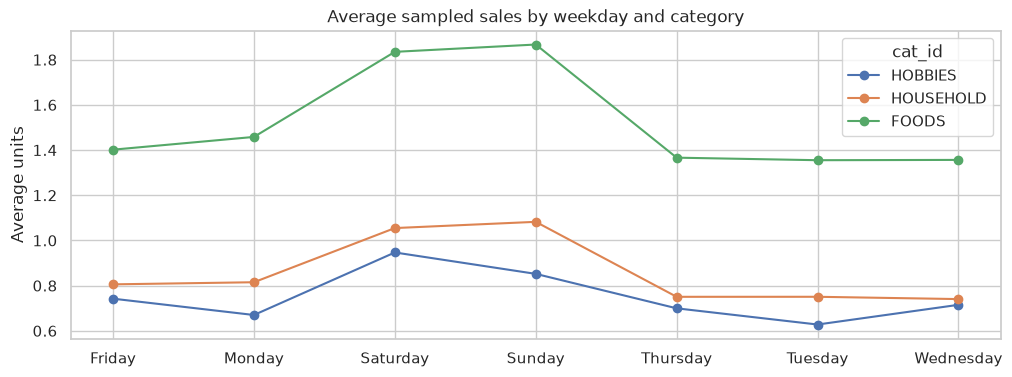

In [19]:
long_sample.groupby(["cat_id", "weekday"])["sales"].mean().unstack(0).plot(figsize=(12, 4), marker="o")
plt.title("Average sampled sales by weekday and category")
plt.xlabel("")
plt.ylabel("Average units")
plt.show()